In [1]:
# Using Nautilus nested sampling to obtain the best fit parameters for the Zhu model given by our real data

import numpy as np
import matplotlib.pyplot as plt
from uniform_slab import *
from nautilus import Prior
from units_astro import *
from nautilus import Sampler
import corner
from numpy import exp, log, log10, sqrt


In [2]:
# now for any parameter
def error_param(data, data_max, N=1000):
    array=np.zeros(N)
    bin=-15
    delta=30/len(array)
    for i in range(len(array)):
        array[i]=len(data[(data>bin) & (data<bin+delta)])
        bin+=delta

    # where we have the maximun
    bin_max=int((data_max+15)/delta)
    # now i want to know where is the 68% of the data
    sum=0
    i=0
    normalization=float(np.sum(array[bin_max:]))
    while sum<0.68*normalization:
        sum+=array[i+bin_max]
        i+=1

    # to the other side
    sum=0
    j=0
    normalization=float(np.sum(array[:bin_max]))
    while sum<0.68*normalization:
        sum+=array[bin_max-j]
        j+=1

    return (bin_max-j)*delta-15-data_max, (i+bin_max)*delta-15-data_max

def upper_limit(data, under_bound, N=1000):
    array=np.zeros(N)
    bin=float(under_bound)
    delta=(15-under_bound)/len(array)
    print(delta)
    for i in range(len(array)):
        array[i]=len(data[(data>bin) & (data<bin+delta)])
        bin+=delta
        
    # now i want to know where is the 99% of the data
    sum=0
    i=N-1
    normalization=float(np.sum(array))
    while sum<0.005*normalization:
        sum+=array[i]
        i-=1

    return (i)*delta+under_bound

In [3]:
# First our data with the error bars
nus = [97.5E9, 145005402197.7, 343.5E9, 671E9] # [nu1, nu2] are the x-axis values , 671E9
Fnus = [12e-06, 21.4e-06, 0.000121, 0.000143] # [Fnu1, Fnu2] are the y-axis values in Jy , 0.000122
sFnus = [4.7e-06, 4.1e-06, 0.000013, 0.000115] # [sigma_Fnu1, sigma_Fnu2] are the y-axis errors in Jy , 0.000090

# To mJy
nu = np.array(nus)
Fnus = np.array(Fnus)*1E3
sFnus = np.array(sFnus)*1E3


prior = Prior()
prior.add_parameter('log_T', dist=(-15, 15))
prior.add_parameter('log_EM', dist=(-15,15))
prior.add_parameter('log_Rmax', dist=(-15, 15))


In [4]:
# For log_alpha=-2
def likelihood(param_dict):
    T = 10**param_dict['log_T']
    EM = 10**param_dict['log_EM']*pc # cm^-6 pc
    Rmax = 10**param_dict['log_Rmax']
    
    ymodels = np.zeros(len(Fnus))
    Xis = np.zeros(len(Fnus))
    for i in range(len(Fnus)):
        ymodels[i] = F_uniform_slab(Rmax*au, T, EM, nu[i])
        Xis[i] = -0.5*((Fnus[i]-ymodels[i])/sFnus[i])**2
        
    return np.sum(Xis)

In [5]:
dict= {'log_T': 4, 'log_EM': 26, 'log_Rmax': 0}
likelihood(dict)

np.float64(-206755451.436368)

In [6]:
# Corro el nested sampling de nautilus
sampler = Sampler(prior, likelihood, n_live=1000, pool=16)
sampler.run(verbose=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 21     | 1        | 4        | 27776    | N/A    | 10019 | -13.52   


np.True_

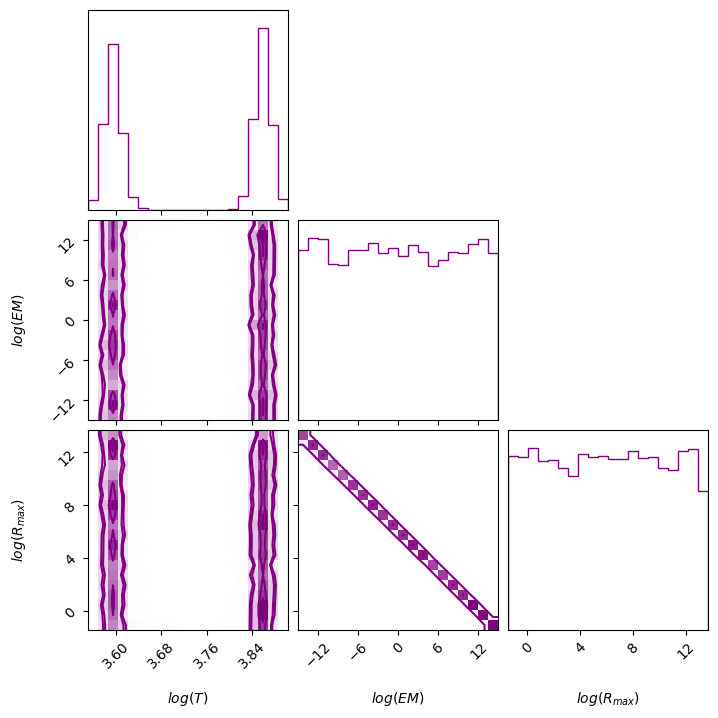

In [7]:
# Hacemos el corner plot

points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=[r'$log(T)$', r'$log(EM)$', r'$log(R_{max})$'],color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), fontsize=12)

# Save the log Z and the corner plot
np.save('logZ1.npy', log_l)
plt .savefig('corner_plot_ff_parametric.png')
plt.show()

In [8]:
# To see equal weights
points_equalw, log_w_equalw, log_l_equalw = sampler.posterior(equal_weight=True)

In [9]:
print('log(Z) =', log_l)
print('Evidence =', np.exp(log_l))
print('The mean parameters =', np.mean(points, axis=0))
print('Errors =', np.std(points, axis=0))
print('The log likelihood is', likelihood({'log_T': points[np.argmax(log_l)][0], 'log_EM': points[np.argmax(log_l)][1], 'log_Rmax': points[np.argmax(log_l)][2]}))
print('The best fit parameter are T =', 10**points[np.argmax(log_l)][0], 'K', '; EM =', 10**points[np.argmax(log_l)][1] ,'cm^-6*pc', '; Rmax=', 10**points[np.argmax(log_l)][2], 'au')

log(Z) = [-60.97073431 -60.97073431 -60.97073431 ...  -1.0498593   -1.0426793
  -1.05664856]
Evidence = [3.31700810e-27 3.31700810e-27 3.31700810e-27 ... 3.49986990e-01
 3.52508940e-01 3.47618883e-01]
The mean parameters = [3.21940195 0.09736241 5.62095485]
Errors = [3.11984465 8.54338007 5.19690765]
The log likelihood is -1.0384634676184366
The best fit parameter are T = 7223.6989420876625 K ; EM = 455036151685.4892 cm^-6*pc ; Rmax= 1.206936070526346 au


In [10]:
# now making our spectral index best fit for the fluxes
T=10**points[np.argmax(log_l)][0]
EM=10**points[np.argmax(log_l)][1]*pc
Rmax=10**points[np.argmax(log_l)][2]

fluxes = np.zeros(len(nu))
for i in range(len(nu)):
    fluxes[i]=F_uniform_slab(Rmax*au, T, EM, nu[i])
    print('Flux at', round(nu[i]/1E9, 1), 'GHz =', fluxes[i])
    if i>0:
        print('Spectral index is ', (log(fluxes[i])-log(fluxes[i-1]))/(log(nu[i])-log(nu[i-1])))



Flux at 97.5 GHz = 0.00918477382233614
Flux at 145.0 GHz = 0.023664145275971833
Spectral index is  2.3844030062376946
Flux at 343.5 GHz = 0.11437303950568481
Spectral index is  1.8268493746492742
Flux at 671.0 GHz = 0.2665018938109915
Spectral index is  1.2633492765993268


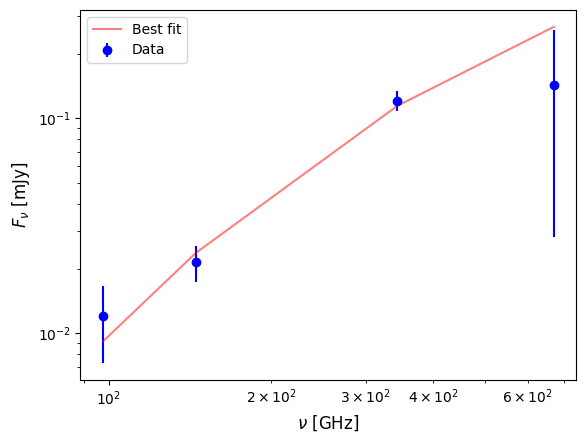

In [11]:
plt.errorbar(np.array(nus)/10**9, Fnus, yerr=sFnus, fmt='o', label='Data', color='blue')
plt.plot(np.array(nus)/10**9, fluxes, label='Best fit', alpha=0.5, color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\nu$ [GHz]', fontsize=12)
plt.ylabel(r'$F_{\nu}$ [mJy]', fontsize=12)
plt.legend(loc='upper left')
plt.savefig('best_fit_ff_zhu_fixed_alpha.png')
plt.show()

In [12]:
# array of frequencies
nu_arr=np.logspace(log10(nus[0]), log10(nus[-1]), 100)

# array of fluxes
F_arr=np.zeros(len(nu_arr))
F_arr_ff=np.zeros(len(nu_arr))
F_arr_zhu=np.zeros(len(nu_arr))

for i in range(len(nu_arr)):
    F_arr_ff[i]=F_uniform_slab(Rmax*au, T, EM, nu_arr[i])


/home/oriana/.local/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


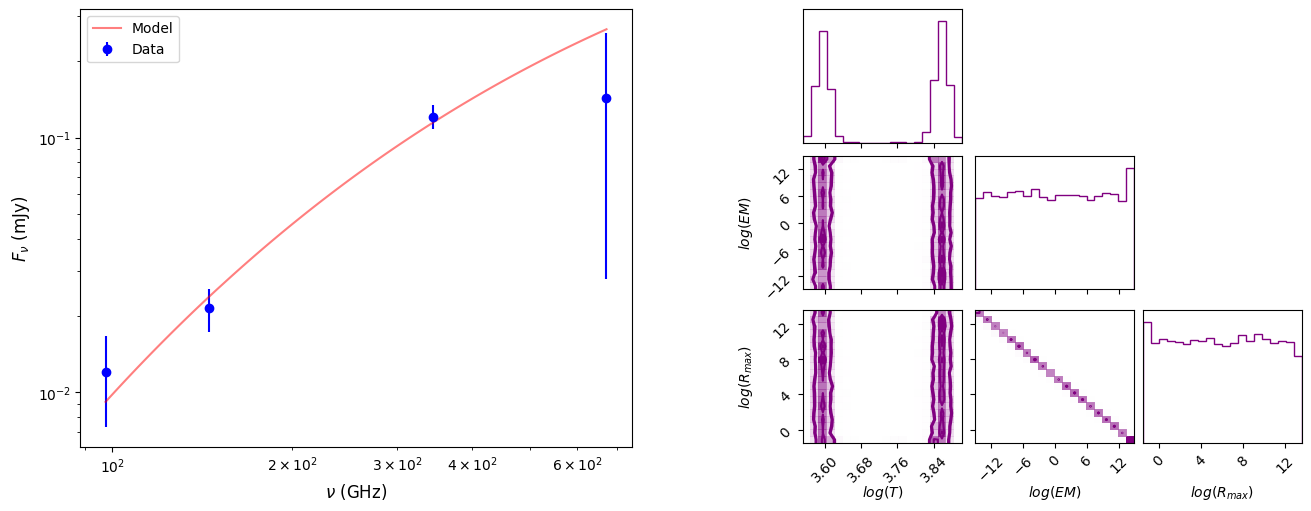

In [13]:
# vs the real data and the corner in the same plot
fig = plt.figure(layout='constrained', figsize=(13, 5))
subfigs = fig.subfigures(1, 2, width_ratios=[1.1, 1], wspace=0.15)

ax1 = subfigs[0].subplots(1, 1, sharey=True)
ax1.errorbar(np.array(nus)/10**9, Fnus, yerr=sFnus, fmt='o', label='Data', color='blue')
#ax1.plot(nu_arr/10**9, F_arr_ff, label='Free-free', linestyle=':', color='black')
#ax1.plot(nu_arr/10**9, F_arr_zhu, label='Dust',linestyle='--', color='green')
ax1.plot(nu_arr/10**9, F_arr_ff, label='Model', alpha=0.5, color='red')
ax1.loglog()
ax1.set_xlabel(r'$\nu$ (GHz)', fontsize=12)
ax1.set_ylabel(r'$F_{\nu}$ (mJy)', fontsize=12)
ax1.legend()


ax2 = subfigs[1]

corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=[r'$log(T)$', r'$log(EM)$', r'$log(R_{max})$'],color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), fontsize=12, fig=ax2)


plt.savefig('fig_ff_uniform_slab.png')
plt.show()



In [14]:
# Now fixing the temperature
prior = Prior()
prior.add_parameter('log_EM', dist=(-15,15))
prior.add_parameter('log_Rmax', dist=(-15, 15))

def likelihood2(param_dict):
    T = 10**3
    EM = 10**param_dict['log_EM']*pc # cm^-6 pc
    Rmax = 10**param_dict['log_Rmax']
    
    ymodels = np.zeros(len(Fnus))
    Xis = np.zeros(len(Fnus))
    for i in range(len(Fnus)):
        ymodels[i] = F_uniform_slab(Rmax*au, T, EM, nu[i])
        Xis[i] = -0.5*((Fnus[i]-ymodels[i])/sFnus[i])**2
        
    return np.sum(Xis)


In [15]:
# Corro el nested sampling de nautilus
sampler = Sampler(prior, likelihood2, n_live=1000, pool=16)
sampler.run(verbose=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 8      | 1        | 4        | 15120    | N/A    | 10063 | -61.11   


np.True_

In [16]:
points, log_w, log_l = sampler.posterior()
points_equalw, log_w_equalw, log_l_equalw = sampler.posterior(equal_weight=True)

In [17]:
print('log(Z) =', log_l)
print('Evidence =', np.exp(log_l))
print('The mean parameters =', np.mean(points, axis=0))
print('Errors =', np.std(points, axis=0))
print('The log likelihood is', likelihood2({'log_EM': points[np.argmax(log_l)][0], 'log_Rmax': points[np.argmax(log_l)][1]}))
print('The best fit parameter are EM =', 10**points[np.argmax(log_l)][0] ,'cm^-6*pc', '; Rmax=', 10**points[np.argmax(log_l)][1], 'au')

log(Z) = [-60.97073431 -60.97073431 -60.97073431 ... -60.19770165 -60.28265454
 -60.25238522]
Evidence = [3.31700810e-27 3.31700810e-27 3.31700810e-27 ... 7.18572102e-27
 6.60048396e-27 6.80333063e-27]
The mean parameters = [0.77698869 2.78038223]
Errors = [8.36646858 8.43438738]
The log likelihood is -60.197498030461645
The best fit parameter are EM = 66355126.136736296 cm^-6*pc ; Rmax= 6966669.609509105 au


In [18]:
# EM, Rmax = points[np.argmax(log_l)]
# EM_min, EM_max = error_param(points_equalw[:,0], EM)
# Rmax_min, Rmax_max = error_param(points_equalw[:,1], Rmax)

# print('EM =', EM, EM_min, EM_max)
# print('Rmax =', Rmax, Rmax_min, Rmax_max)

In [19]:
# now making our spectral index best fit for the fluxes
T=10**3
EM=10**points[np.argmax(log_l)][0]*pc
Rmax=10**points[np.argmax(log_l)][1]

fluxes = np.zeros(len(nu))
for i in range(len(nu)):
    fluxes[i]=F_uniform_slab(Rmax*au, T, EM, nu[i])
    print('Flux at', round(nu[i]/1E9, 1), 'GHz =', fluxes[i])
    if i>0:
        print('Spectral index is ', (log(fluxes[i])-log(fluxes[i-1]))/(log(nu[i])-log(nu[i-1])))


Flux at 97.5 GHz = 1.7265547625783163e-25
Flux at 145.0 GHz = 1.0416371166746207e-18
Spectral index is  39.33491784972254
Flux at 343.5 GHz = 1.636796784352668e-07
Spectral index is  29.893207174425637
Flux at 671.0 GHz = 0.1429877938643656
Spectral index is  20.431191358613273


/home/oriana/.local/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


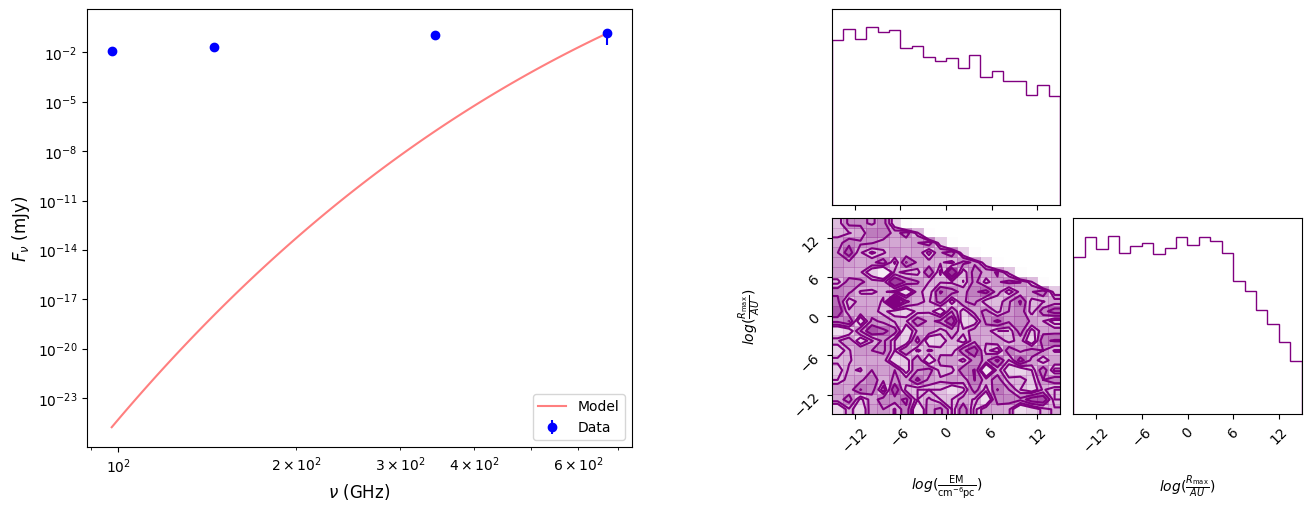

In [20]:
# array of frequencies
nu_arr=np.logspace(log10(nus[0]), log10(nus[-1]), 100)

# array of fluxes
F_arr=np.zeros(len(nu_arr))
F_arr_ff=np.zeros(len(nu_arr))
F_arr_zhu=np.zeros(len(nu_arr))

# vs the real data and the corner in the same plot
for i in range(len(nu_arr)):
    F_arr_ff[i]=F_uniform_slab(Rmax*au, T, EM, nu_arr[i])

fig = plt.figure(layout='constrained', figsize=(13, 5))
subfigs = fig.subfigures(1, 2, width_ratios=[1.1, 1], wspace=0.15)

ax1 = subfigs[0].subplots(1, 1, sharey=True)
ax1.errorbar(np.array(nus)/10**9, Fnus, yerr=sFnus, fmt='o', label='Data', color='blue')
#ax1.plot(nu_arr/10**9, F_arr_ff, label='Free-free', linestyle=':', color='black')
#ax1.plot(nu_arr/10**9, F_arr_zhu, label='Dust',linestyle='--', color='green')
ax1.plot(nu_arr/10**9, F_arr_ff, label='Model', alpha=0.5, color='red')
ax1.loglog()
ax1.set_xlabel(r'$\nu$ (GHz)', fontsize=12)
ax1.set_ylabel(r'$F_{\nu}$ (mJy)', fontsize=12)
ax1.legend()


ax2 = subfigs[1]

corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=[r'$log(\frac{\rm EM}{\rm cm^{-6} pc})$', r'$log(\frac{R_{\rm max}}{AU})$'],color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), fontsize=20, fig=ax2)


plt.savefig('fig_ff_uniform_slab_T1000.png')
plt.show()


In [21]:
# finally T=10000
prior = Prior()
prior.add_parameter('log_EM', dist=(-15,15))
prior.add_parameter('log_Rmax', dist=(-15, 15))

def likelihood3(param_dict):
    T = 10**4
    EM = 10**param_dict['log_EM']*pc # cm^-6 pc
    Rmax = 10**param_dict['log_Rmax']
    
    ymodels = np.zeros(len(Fnus))
    Xis = np.zeros(len(Fnus))
    for i in range(len(Fnus)):
        ymodels[i] = F_uniform_slab(Rmax*au, T, EM, nu[i])
        Xis[i] = -0.5*((Fnus[i]-ymodels[i])/sFnus[i])**2
        
    return np.sum(Xis)


In [22]:
# Corro el nested sampling de nautilus
sampler2 = Sampler(prior, likelihood3, n_live=1000, pool=16)
sampler2.run(verbose=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 15     | 1        | 4        | 21280    | N/A    | 10046 | -39.81   


np.True_

In [23]:
points2, log_w2, log_l2 = sampler2.posterior()
points_equalw2, log_w_equalw2, log_l_equalw2 = sampler2.posterior(equal_weight=True)
print('log(Z) =', log_l2)
print('Evidence =', np.exp(log_l2))
print('The mean parameters =', np.mean(points2, axis=0))
print('Errors =', np.std(points2, axis=0))
print('The log likelihood is', likelihood3({'log_EM': points2[np.argmax(log_l)][0], 'log_Rmax': points2[np.argmax(log_l)][1]}))
print('The best fit parameter are EM =', 10**points2[np.argmax(log_l)][0] ,'cm^-6*pc', '; Rmax=', 10**points2[np.argmax(log_l)][1], 'au')
# now making our spectral index best fit for the fluxes
T=10**4
EM=10**points2[np.argmax(log_l2)][0]*pc
Rmax=10**points2[np.argmax(log_l2)][1]

fluxes2 = np.zeros(len(nu))
for i in range(len(nu)):
    fluxes2[i]=F_uniform_slab(Rmax*au, T, EM, nu[i])
    print('Flux at', round(nu[i]/1E9, 1), 'GHz =', fluxes2[i])
    if i>0:
        print('Spectral index is ', (log(fluxes2[i])-log(fluxes2[i-1]))/(log(nu[i])-log(nu[i-1])))


log(Z) = [-6.01609981e+20 -6.09707343e+01 -6.09707343e+01 ... -3.34536789e+01
 -3.36676300e+01 -3.36837363e+01]
Evidence = [0.00000000e+00 3.31700810e-27 3.31700810e-27 ... 2.95972826e-15
 2.38964874e-15 2.35146867e-15]
The mean parameters = [1.61586313 4.69831151]
Errors = [9.32539897 5.41892795]
The log likelihood is -33.95590587786539
The best fit parameter are EM = 9708484564.933008 cm^-6*pc ; Rmax= 32.157511540167135 au
Flux at 97.5 GHz = 6.605450804185717e-05
Flux at 145.0 GHz = 0.0009077259946185817
Spectral index is  6.602013991466897
Flux at 343.5 GHz = 0.06615057576093067
Spectral index is  4.972943155534683
Flux at 671.0 GHz = 0.6210838666737396
Spectral index is  3.3446724146946134


In [24]:
# EM, Rmax = points[np.argmax(log_l)]
# EM_min, EM_max = error_param(points_equalw[:,0], EM)
# Rmax_min, Rmax_max = error_param(points_equalw[:,1], Rmax)

# print('EM =', EM, EM_min, EM_max)
# print('Rmax =', Rmax, Rmax_min, Rmax_max)

In [25]:
# array of frequencies
nu_arr=np.logspace(log10(nus[0]), log10(nus[-1]), 100)

# array of fluxes
F_arr2=np.zeros(len(nu_arr))
F_arr_ff2=np.zeros(len(nu_arr))
F_arr_zhu2=np.zeros(len(nu_arr))

# vs the real data and the corner in the same plot
for i in range(len(nu_arr)):
    F_arr_ff2[i]=F_uniform_slab(Rmax*au, T, EM, nu_arr[i])




/home/oriana/.local/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


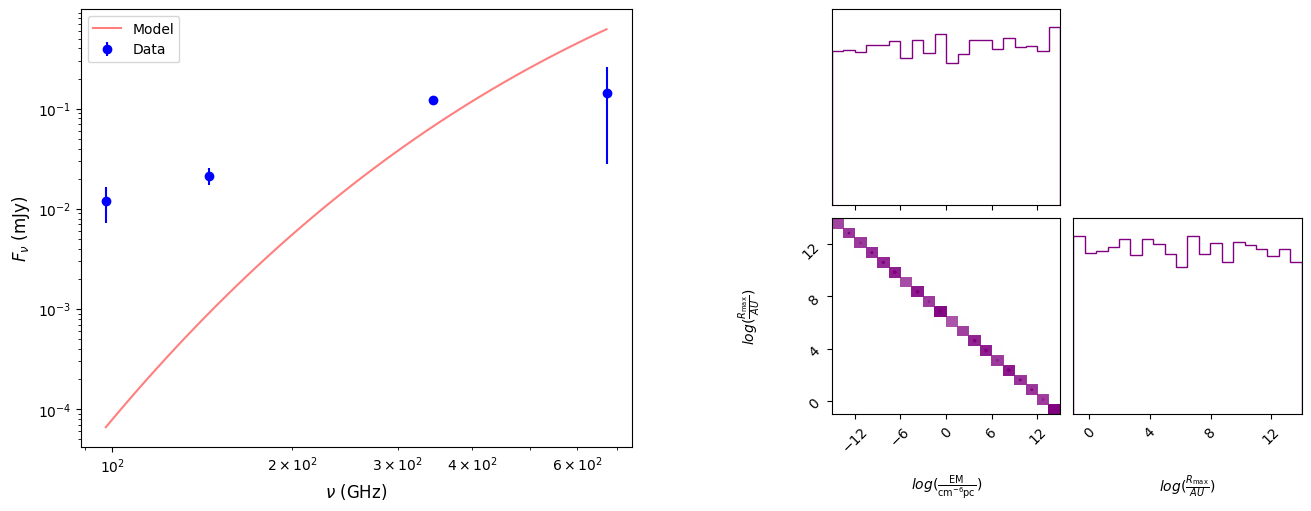

In [26]:
fig = plt.figure(layout='constrained', figsize=(13, 5))
subfigs = fig.subfigures(1, 2, width_ratios=[1.1, 1], wspace=0.15)

ax1 = subfigs[0].subplots(1, 1, sharey=True)
ax1.errorbar(np.array(nus)/10**9, Fnus, yerr=sFnus, fmt='o', label='Data', color='blue')
#ax1.plot(nu_arr/10**9, F_arr_ff, label='Free-free', linestyle=':', color='black')
#ax1.plot(nu_arr/10**9, F_arr_zhu, label='Dust',linestyle='--', color='green')
ax1.plot(nu_arr/10**9, F_arr_ff2, label='Model', alpha=0.5, color='red')
ax1.loglog()
ax1.set_xlabel(r'$\nu$ (GHz)', fontsize=12)
ax1.set_ylabel(r'$F_{\nu}$ (mJy)', fontsize=12)
ax1.legend(loc='upper left')


ax2 = subfigs[1]

corner.corner(
    points2, weights=np.exp(log_w2), bins=20, labels=[r'$log(\frac{\rm EM}{\rm cm^{-6} pc})$', r'$log(\frac{R_{\rm max}}{AU})$'],color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), fontsize=20, fig=ax2)


plt.savefig('fig_ff_uniform_slab_T10000.png')
plt.show()

In [27]:
# to inches the column and the text width
column_width=256.0748*0.0138888889
text_width=523.5307*0.0138888889

In [28]:
# to inches the column and the text width
column_width=256.0748*0.0138888889
text_width=523.5307*0.0138888889
print('Column width =', column_width, 'inches')
print('Text width =', text_width, 'inches')

Column width = 3.55659444728972 inches
Text width = 7.27125972803923 inches


/home/oriana/.local/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


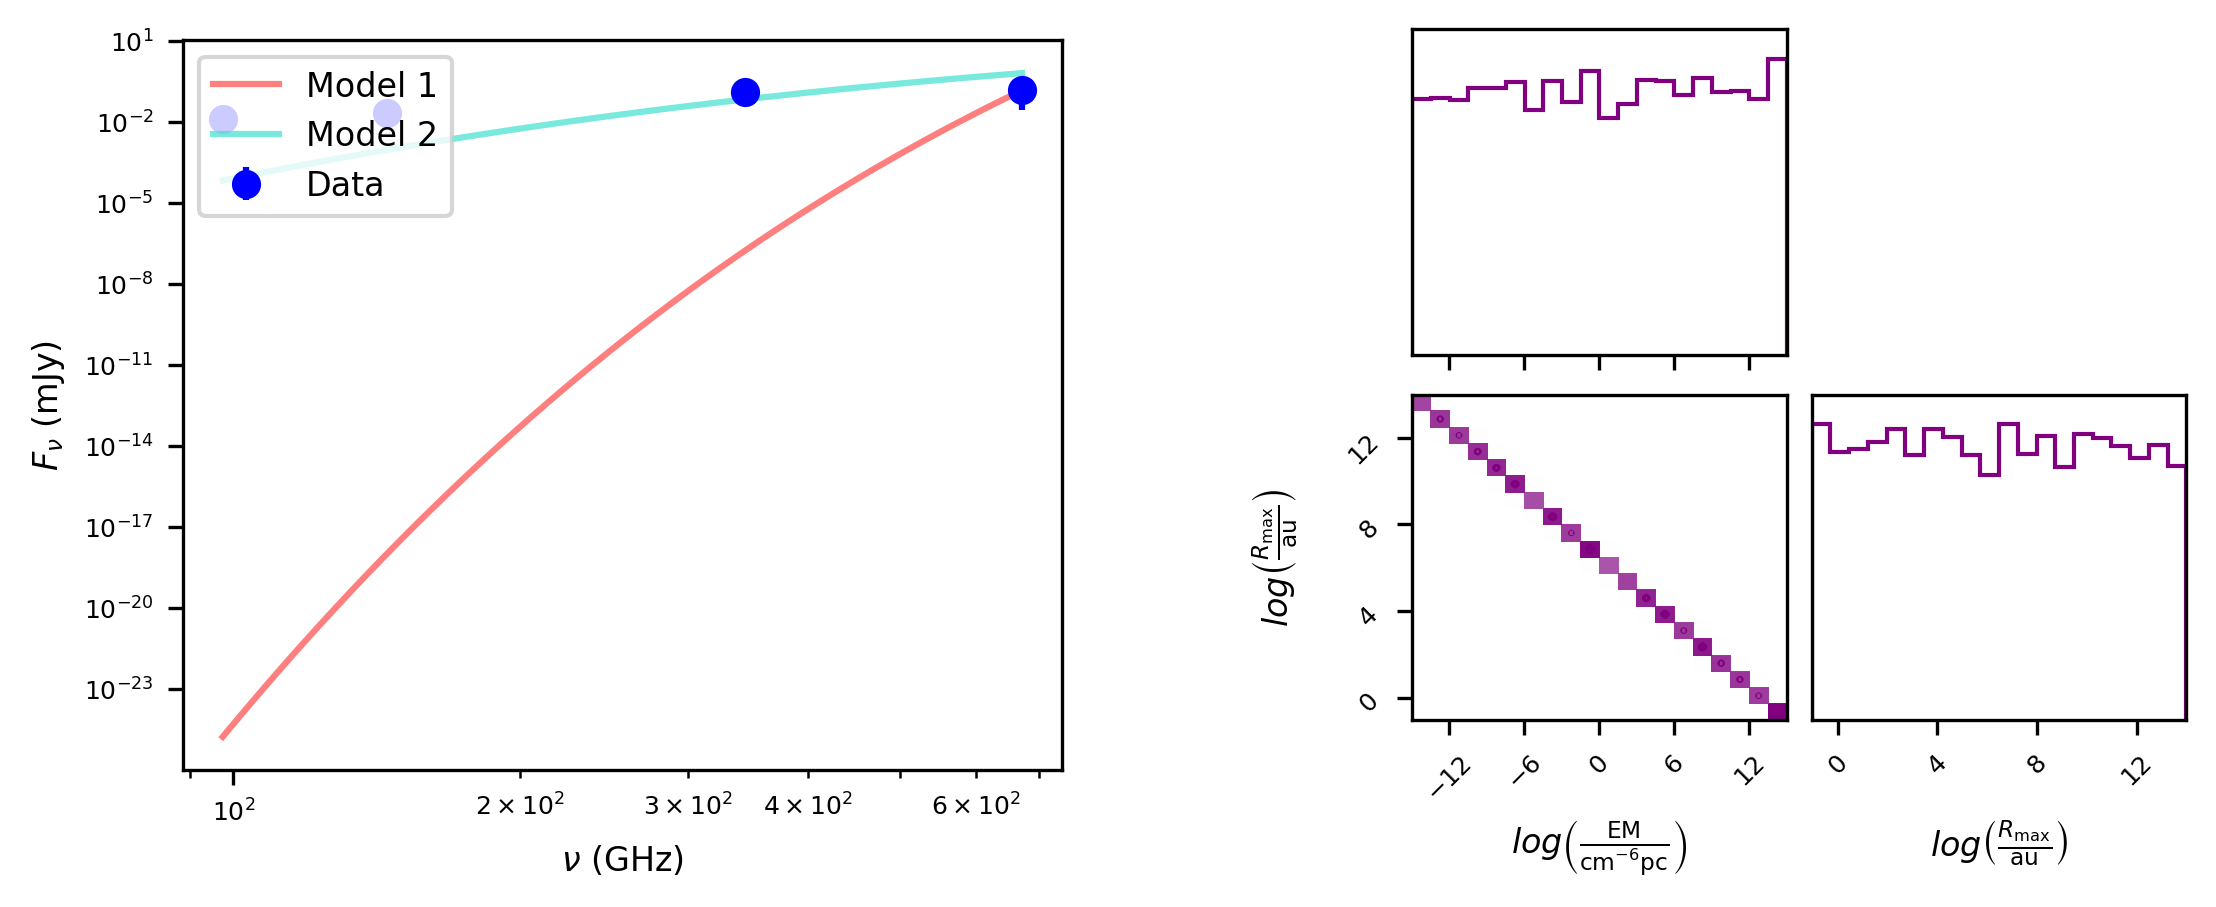

In [29]:
fig = plt.figure(layout='constrained', figsize=(text_width, text_width/(2.5)), dpi=300)
subfigs = fig.subfigures(1, 2, width_ratios=[1.1, 1], wspace=0.15)

ax1 = subfigs[0].subplots(1, 1, sharey=True)
ax1.errorbar(np.array(nus)/10**9, Fnus, yerr=sFnus, fmt='o', label='Data', color='blue')
#ax1.plot(nu_arr/10**9, F_arr_ff, label='Free-free', linestyle=':', color='black')
#ax1.plot(nu_arr/10**9, F_arr_zhu, label='Dust',linestyle='--', color='green')
ax1.plot(nu_arr/10**9, F_arr_ff, label='Model 1', alpha=0.5, color='red')
ax1.plot(nu_arr/10**9, F_arr_ff2, label='Model 2', alpha=0.7, color='turquoise')
ax1.loglog()
ax1.tick_params(axis='both', which='minor', labelsize=6)
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.set_xlabel(r'$\nu$ (GHz)', fontsize=8)
ax1.set_ylabel(r'$F_{\nu}$ (mJy)', fontsize=8)
ax1.legend(loc='upper left', fontsize=8)


ax2 = subfigs[1]

corner.corner(
    points2, weights=np.exp(log_w2), bins=20, labels=[r'$log\left(\frac{\rm EM}{\rm cm^{-6} pc}\right)$', r'$log\left(\frac{R_{\rm max}}{\rm au}\right)$'], color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), fig=ax2, label_kwargs={'fontsize': 8})

for axs in ax2.get_axes():
    axs.tick_params(axis='both', labelsize=6)

plt.savefig('fig_uniform_slab.png', bbox_inches='tight',dpi=300)
plt.show()

In [30]:
# plot a example fixing a big EM =10^30
prior = Prior()
prior.add_parameter('log_T', dist=(-15, 15))
prior.add_parameter('log_Rmax', dist=(-15, 15))

def likelihood4(param_dict):
    T = 10**param_dict['log_T']
    EM = 10**30*pc # cm^-6 pc
    Rmax = 10**param_dict['log_Rmax']
    
    ymodels = np.zeros(len(Fnus))
    Xis = np.zeros(len(Fnus))
    for i in range(len(Fnus)):
        ymodels[i] = F_uniform_slab(Rmax*au, T, EM, nu[i])
        Xis[i] = -0.5*((Fnus[i]-ymodels[i])/sFnus[i])**2
        
    return np.sum(Xis)



In [31]:
# Corro el nested sampling de nautilus
sampler = Sampler(prior, likelihood4, n_live=1000, pool=16)
sampler.run(verbose=True)


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 18     | 1        | 4        | 21952    | N/A    | 10100 | -10.42   


np.True_

In [32]:
points, log_w, log_l = sampler.posterior()
points_equalw, log_w_equalw, log_l_equalw = sampler.posterior(equal_weight=True)
print('log(Z) =', log_l)
print('Evidence =', np.exp(log_l))
print('The mean parameters =', np.mean(points, axis=0))
print('Errors =', np.std(points, axis=0))
print('The log likelihood is', likelihood4({'log_T': points[np.argmax(log_l)][0], 'log_Rmax': points[np.argmax(log_l)][1]}))
print('The best fit parameter are T =', 10**points[np.argmax(log_l)][0] ,'K', '; Rmax=', 10**points[np.argmax(log_l)][1], 'au')
# now making our spectral index best fit for the fluxes
T=10**points[np.argmax(log_l)][0]
EM=10**30*pc
Rmax=10**points[np.argmax(log_l)][1]

fluxes = np.zeros(len(nu))
for i in range(len(nu)):
    fluxes[i]=F_uniform_slab(Rmax*au, T, EM, nu[i])
    print('Flux at', round(nu[i]/1E9, 1), 'GHz =', fluxes[i])
    if i>0:
        print('Spectral index is ', (log(fluxes[i])-log(fluxes[i-1]))/(log(nu[i])-log(nu[i-1])))


log(Z) = [-60.97073431 -60.97073431 -60.97073431 ...  -1.37206252  -1.418915
  -1.40589009]
Evidence = [3.31700810e-27 3.31700810e-27 3.31700810e-27 ... 2.53583400e-01
 2.41976419e-01 2.45148755e-01]
The mean parameters = [ 5.06868589 -2.54724819]
Errors = [5.30812637 3.83515361]
The log likelihood is -1.363975000178177
The best fit parameter are T = 21.468902139439393 K ; Rmax= 0.6008454157848656 au
Flux at 97.5 GHz = 0.011862298625928455
Flux at 145.0 GHz = 0.024821470655049614
Spectral index is  1.8601894823075489
Flux at 343.5 GHz = 0.10935570015395929
Spectral index is  1.719467922141287
Flux at 671.0 GHz = 0.27045751119108363
Spectral index is  1.3523498291029008


/home/oriana/.local/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


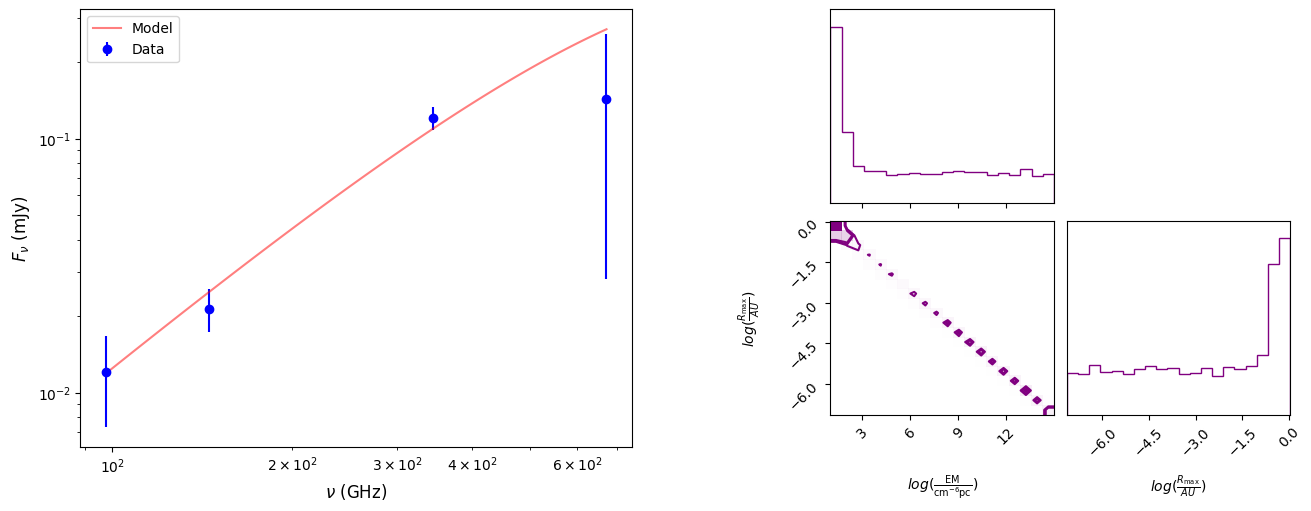

In [33]:
# array of frequencies
nu_arr=np.logspace(log10(nus[0]), log10(nus[-1]), 100)

# array of fluxes
F_arr=np.zeros(len(nu_arr))
F_arr_ff=np.zeros(len(nu_arr))
F_arr_zhu=np.zeros(len(nu_arr))

# vs the real data and the corner in the same plot
for i in range(len(nu_arr)):
    F_arr_ff[i]=F_uniform_slab(Rmax*au, T, EM, nu_arr[i])

fig = plt.figure(layout='constrained', figsize=(13, 5))
subfigs = fig.subfigures(1, 2, width_ratios=[1.1, 1], wspace=0.15)

ax1 = subfigs[0].subplots(1, 1, sharey=True)
ax1.errorbar(np.array(nus)/10**9, Fnus, yerr=sFnus, fmt='o', label='Data', color='blue')
#ax1.plot(nu_arr/10**9, F_arr_ff, label='Free-free', linestyle=':', color='black')
#ax1.plot(nu_arr/10**9, F_arr_zhu, label='Dust',linestyle='--', color='green')
ax1.plot(nu_arr/10**9, F_arr_ff, label='Model', alpha=0.5, color='red')
ax1.loglog()
ax1.set_xlabel(r'$\nu$ (GHz)', fontsize=12)
ax1.set_ylabel(r'$F_{\nu}$ (mJy)', fontsize=12)
ax1.legend()


ax2 = subfigs[1]

corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=[r'$log(\frac{\rm EM}{\rm cm^{-6} pc})$', r'$log(\frac{R_{\rm max}}{AU})$'],color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), fontsize=20, fig=ax2)


plt.savefig('fig_ff_uniform_slab_EM.png')
plt.show()
